# Land Degradation and Rangeland Dynamics

This notebook runs the `land_degradation` module for an approximate northern
Burkina Faso AOI. It evaluates vegetation trends, bare-soil indicators, terrain,
rainfall anomaly, and land cover, then reports degradation classes, NDVI trend
statistics, structural breakpoints, and model drivers.


## Before you run

Land-degradation detection needs a long record. Use at least 5 years, with 10 or
more years preferred. A 1 km scale is a practical starting point for regional
analysis.


In [1]:
from dataclasses import asdict
from pathlib import Path
import os

from IPython import get_ipython

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt
from dotenv import load_dotenv

from climate_change import USE_CASE_REGISTRY, run_analysis

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "pyproject.toml").exists() else Path.cwd().parent
load_dotenv(PROJECT_ROOT / ".env")

GEE_PROJECT = os.environ.get("GEE_PROJECT", "").strip()
if not GEE_PROJECT:
    raise RuntimeError(
        "Set GEE_PROJECT in your shell or in the repository .env file before running this notebook."
    )

OUTPUT_DIR = PROJECT_ROOT / "outputs"
REPORT_DIR = PROJECT_ROOT / "reports"
OUTPUT_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)

In [2]:
module_info = USE_CASE_REGISTRY["land_degradation"]
print(module_info.name)
print(module_info.date_guidance)
print("Models:", [option.id for option in module_info.model_options])

Rangeland Dynamics & Land Degradation
Select at least 5 years for meaningful trend detection; 10+ years recommended.
Models: ['rf', 'lgbm', 'ensemble']


In [3]:
# Approximate Sahelian zone in northern Burkina Faso.
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [-2.80, 13.20],
            [-0.20, 13.20],
            [-0.20, 15.00],
            [-2.80, 15.00],
            [-2.80, 13.20],
        ]
    ],
}

analysis_args = {
    "module": "land_degradation",
    "aoi_geojson": aoi,
    "start_date": "2015-01-01",
    "end_date": "2024-12-31",
    "country": "Burkina Faso",
    "gee_project": GEE_PROJECT,
    "extra_params": {
        "model_type": "lgbm",  # "rf", "lgbm", or "ensemble"
        "n_pixels": 3000,
        "scale": 1000,
        "output_dir": str(OUTPUT_DIR),
        "prefix": "burkina_land_degradation",
    },
}

In [4]:
output = await run_analysis(**analysis_args)

2026-06-24 14:02:37,062 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
/home/odero-george/workspace/climate-change/.venv/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 42831 instead
  warnings.warn(
2026-06-24 14:02:37,085 - distributed.scheduler - INFO - State start
2026-06-24 14:02:37,088 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:40177
2026-06-24 14:02:37,089 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:42831/status
2026-06-24 14:02:37,089 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-06-24 14:02:37,099 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:38819'
2026-06-24 14:02:37,101 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:34219'
2

In [5]:
print("Module:", output.module)
print("Raster output:", output.raster_path)
print("GeoJSON features:", len(output.geojson.get("features", [])))
print("Chart keys:", sorted(output.charts))
print("Metadata:", output.metadata)
output.stats

Module: land_degradation
Raster output: {'degradation_risk': '/home/odero-george/workspace/climate-change/outputs/burkina_land_degradation_degradation_risk.tif'}
GeoJSON features: 1
Chart keys: ['model_performance', 'riskDist', 'shap', 'timeSeries', 'trend']
Metadata: {'model': 'lgbm', 'country': 'Burkina Faso', 'start_date': '2015-01-01', 'end_date': '2024-12-31', 'raster': {'degradation_risk': '/home/odero-george/workspace/climate-change/outputs/burkina_land_degradation_degradation_risk.tif'}}


{'model_type': 'lgbm',
 'n_pixels_sampled': 2997,
 'degraded_label_pct': 30.0,
 'rf_cv_f1': 0.9311,
 'rf_f1': 0.9356,
 'rf_accuracy': 0.935,
 'lgbm_cv_f1': 0.9629,
 'lgbm_f1': 0.97,
 'lgbm_accuracy': 0.97,
 'ensemble_f1': 0.9458,
 'selected_f1': 0.97,
 'top_degradation_driver': 'ndvi_slope',
 'ndvi_trend_per_year': 0.00604,
 'ndvi_trend_r2': 0.8044,
 'ndvi_trend_p': 0.0004,
 'mk_tau': 0.7778,
 'mk_p': 0.0009,
 'mk_significant': True,
 'breakpoint_years': [2017, 2019, 2022],
 'breakpoint_year': 2017,
 'country': 'Burkina Faso'}

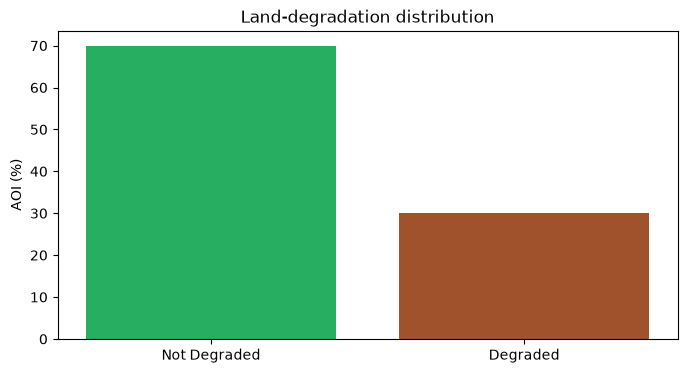

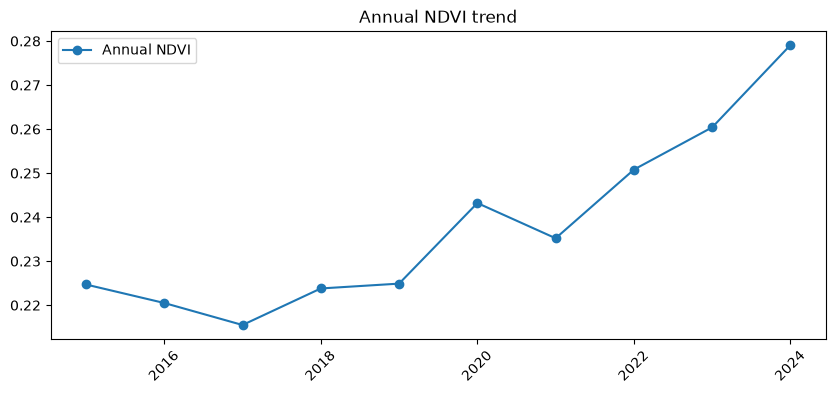

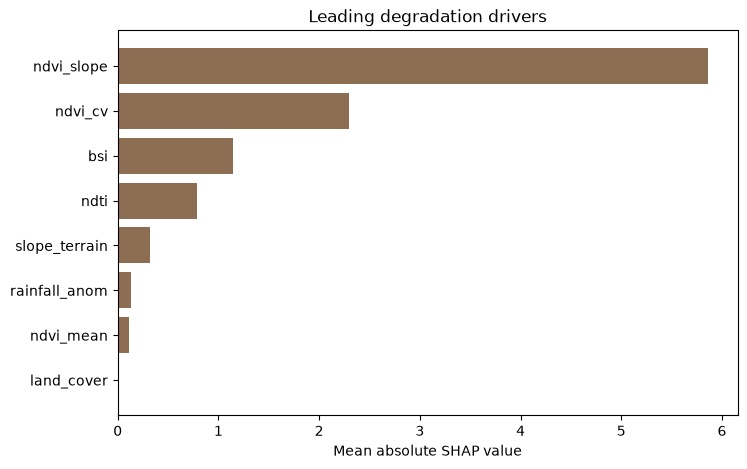

In [6]:
risk = output.charts.get("riskDist", {})
if risk.get("labels"):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(risk["labels"], risk["data"], color=["#27AE60", "#A0522D"])
    ax.set_ylabel("AOI (%)")
    ax.set_title("Land-degradation distribution")
    plt.show()

series = output.charts.get("timeSeries", {})
if series.get("labels"):
    fig, ax = plt.subplots(figsize=(10, 4))
    for dataset in series.get("datasets", []):
        ax.plot(
            series["labels"],
            dataset["data"],
            marker="o",
            label=dataset["label"],
        )
    ax.set_title("Annual NDVI trend")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
    plt.show()

shap = output.shap or output.charts.get("shap", {})
if shap.get("features"):
    features = shap["features"][:8][::-1]
    values = shap["mean_abs_shap"][:8][::-1]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(features, values, color="#8E6E53")
    ax.set_title("Leading degradation drivers")
    ax.set_xlabel("Mean absolute SHAP value")
    plt.show()

In [7]:
# Optional: generate a PDF report in a second call.
# Set this to True only when you want the extra analysis/report run.
GENERATE_REPORT = True

if GENERATE_REPORT:
    report_output = await run_analysis(
        **analysis_args,
        report_output_dir=str(REPORT_DIR),
    )
    print("Report:", report_output.metadata.get("report_path"))

Report: /home/odero-george/workspace/climate-change/reports/land_degradation_20260624_110408.pdf
